In [29]:
import numpy as np
import matplotlib.pyplot as plt


In [30]:
def mykdenvar(xt,X,h):

    N = X.shape[0]
    n = X.shape[1]

    px = 0

    for i in range(N):
        d = xt - X[i,:]
        u = d/h
        px += np.exp(-0.5*np.dot(u,u))

        print(px)
    
    px = px / (N * (h**n) * ((2*np.pi)**(n)))
    return px

In [31]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# plt.figure(figsize=(10,7))
# plt.scatter(X[:,0],X[:,1],c=y)
# plt.xlabel(data.feature_names[0])
# plt.ylabel(data.feature_names[1])
# plt.title('Breast Cancer Wisconsin (Diagnostic) Data Set')
# plt.show()

X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Erro : 1.4903339191564147


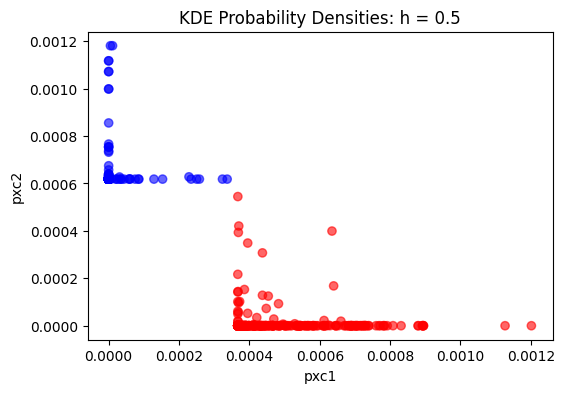

Erro : 1.4499121265377857


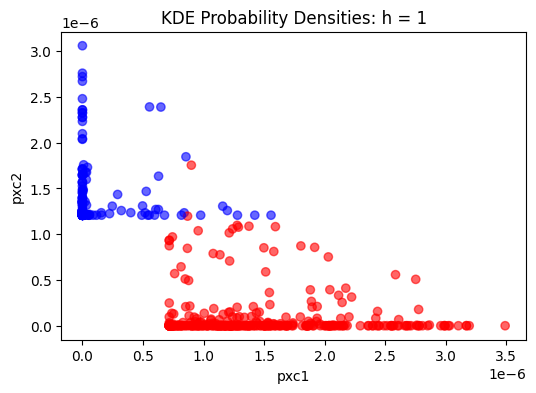

Erro : 1.358523725834798


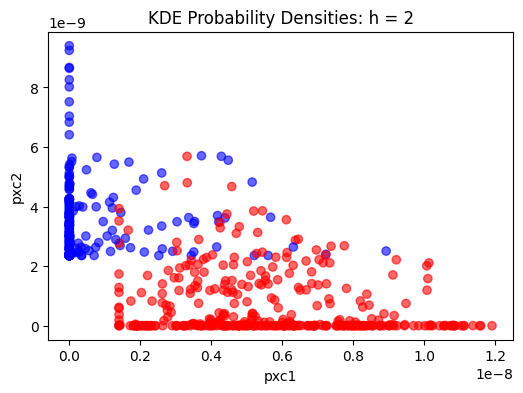

Erro : 1.242530755711775


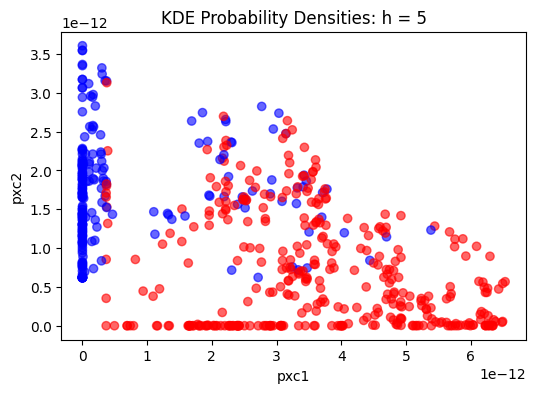

Erro : 1.2442882249560632


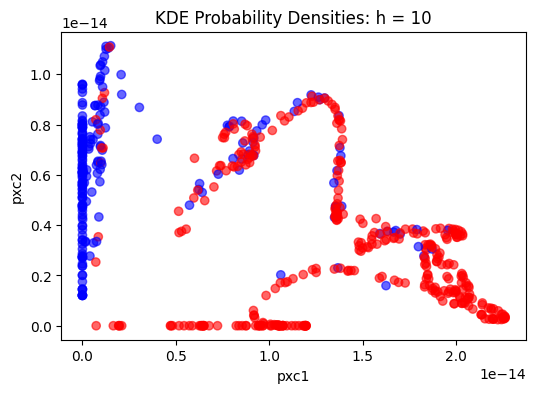

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
xall = pd.DataFrame(data.data[:, 2:11]) 
yall = data.target                        

def mykdenvar(xt, X, h):
    N, n = X.shape
    px = 0.0
    for i in range(N):
        u = (xt - X[i, :]) / h
        px += np.exp(-0.5 * np.dot(u, u))
    px = px / (N * (h ** n) * ((2 * np.pi) ** (n / 2)))
    return px

idxc1 = np.where(yall == 1)[0]
idxc2 = np.where(yall == 0)[0]  

xc1 = xall.iloc[idxc1, :].to_numpy()
xc2 = xall.iloc[idxc2, :].to_numpy()

Nall = xall.shape[0]
N1 = xc1.shape[0]
N2 = xc2.shape[0]

pc1 = N1 / Nall
pc2 = N2 / Nall

h_list = [0.5,1,2,5,10]

for h in h_list:

    yhat = np.zeros(Nall)
    pxc1_array = np.zeros(Nall)
    pxc2_array = np.zeros(Nall)
    for i in range(Nall):
        xt = xall.iloc[i, :].to_numpy()
        pxc1 = mykdenvar(xt, xc1, h)
        pxc2 = mykdenvar(xt, xc2, h)
        px = mykdenvar(xt, xall.to_numpy(), h)
        
        pc1x = pxc1 * pc1 / px
        pc2x = pxc2 * pc2 / px
        
        yhat[i] = np.sign(pc2x - pc1x)
        
        pxc1_array[i] = pxc1
        pxc2_array[i] = pxc2

    yallsign = 2 * (yall - 1.5)  

    acc = np.sum((yhat - yallsign) ** 2) / (4)
    print("Erro :", acc/Nall)

    colors = np.array(['red', 'blue'])
    plt.figure(figsize=(6,4))
    plt.scatter(pxc1_array, pxc2_array, c=colors[((yallsign+1)/2).astype(int)], alpha=0.6)
    plt.xlabel("pxc1")
    plt.ylabel("pxc2")
    plt.title(f"KDE Probability Densities: h = {h}")
    plt.show()


In [99]:
yallsign

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 2., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 2., 2., 2.,
       2., 2., 0., 0., 2., 0., 0., 2., 2., 2., 2., 0., 2., 0., 0., 2., 2.,
       2., 2., 0., 2., 0., 0., 2., 0., 2., 0., 0., 2., 2., 2., 0., 0., 2.,
       0., 0., 0., 2., 2., 2., 0., 2., 2., 0., 0., 2., 2., 2., 0., 0., 2.,
       2., 2., 2., 0., 2., 2., 0., 2., 2., 2., 2., 2., 2., 2., 2., 0., 0.,
       0., 2., 0., 0., 2., 2., 2., 0., 0., 2., 0., 2., 0., 0., 2., 0., 0.,
       2., 2., 0., 2., 2., 0., 2., 2., 2., 2., 0., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 0., 2., 2., 2., 2., 0., 0., 2., 0., 2., 2., 0., 0., 2.,
       2., 0., 0., 2., 2., 2., 2., 0., 2., 2., 0., 0., 0., 2., 0., 2., 0.,
       2., 2., 2., 0., 2., 2., 0., 0., 2., 0., 0., 0., 0., 2., 0., 0., 0.,
       2., 0., 2., 0., 2., 2., 0., 2., 0., 0., 0., 0., 2., 2., 0., 0., 2.,
       2., 2., 0., 2., 2.

In [96]:
((yallsign+1)/2).astype(int)

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1,  0,  0,  0,
        0,  0, -1, -1,  0, -1, -1,  0,  0,  0,  0, -1,  0, -1, -1,  0,  0,
        0,  0, -1,  0, -1, -1,  0, -1,  0, -1, -1,  0,  0,  0, -1, -1,  0,
       -1, -1, -1,  0,  0,  0, -1,  0,  0, -1, -1,  0,  0,  0, -1, -1,  0,
        0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,
       -1,  0, -1, -1,  0,  0,  0, -1, -1,  0, -1,  0, -1, -1,  0, -1, -1,
        0,  0, -1,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0,  0, -1, -1,  0,
        0, -1, -1,  0,  0,  0,  0, -1,  0,  0, -1, -1, -1,  0, -1,  0, -1,
        0,  0,  0, -1,  0,  0, -1, -1,  0, -1, -1, -1, -1,  0, -1, -1, -1,
        0, -1,  0, -1,  0,  0, -1,  0, -1, -1, -1, -1,  0,  0, -1, -1,  0,
        0,  0, -1,  0,  0